Isochrone has 30 mass points.
First 30 masses:
[0.01  0.015 0.02  0.03  0.04  0.05  0.06  0.07  0.072 0.075 0.08  0.09
 0.1   0.11  0.13  0.15  0.17  0.2   0.3   0.4   0.5   0.6   0.7   0.8
 0.9   1.    1.1   1.2   1.3   1.4  ]
Min/Max mass on isochrone: 0.01 1.4

Interpolated params at 0.3540 Msun:
  Teff = 3468.01 K
  logg = 4.029 (cgs)


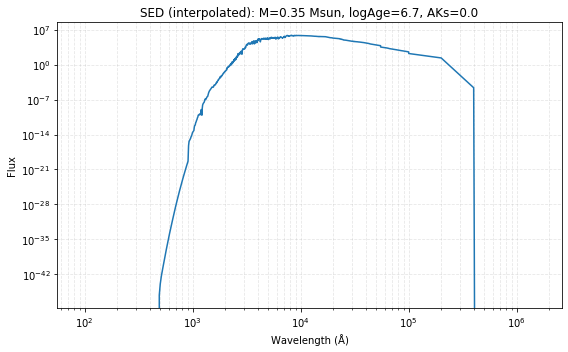

In [2]:
from spisea import synthetic, evolution, atmospheres, reddening
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ----------------------------
# User settings
# ----------------------------
target_mass = 0.354          # Msun (can be off-grid)
log_age = 6.7              # log10(years)
metallicity = 0.0          # [Z] for atmosphere call
AKs = 0.0
distance = 10_000          # pc

# Choose models (use whatever you’re standardizing on)
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# If you want the isochrone to include photometric filters too, add filters=[...]
# but for Teff/logg/mass you don't need them.

# ----------------------------
# Build isochrone
# ----------------------------
iso = synthetic.IsochronePhot(
    log_age, AKs, distance,
    metallicity=metallicity,
    evo_model=evo_model,
    atm_func=atm_func,
    red_law=red_law,
    # filters=[...]  # optional
)

points = iso.points  # astropy table

# ----------------------------
# List masses available on the isochrone
# ----------------------------
mass_grid = np.array(points["mass"], dtype=float)

print(f"Isochrone has {len(mass_grid)} mass points.")
print("First 30 masses:")
print(mass_grid[:30])
print("Min/Max mass on isochrone:", mass_grid.min(), mass_grid.max())

# Optionally print them all (can be long)
# print(mass_grid)

# ----------------------------
# Interpolate Teff/logg to target_mass
# ----------------------------
teff_grid = np.array(points["Teff"], dtype=float)
logg_grid = np.array(points["logg"], dtype=float)

# Sort by mass (important for interp1d)
order = np.argsort(mass_grid)
mass_sorted = mass_grid[order]
teff_sorted = teff_grid[order]
logg_sorted = logg_grid[order]

# Guard: don’t silently extrapolate unless you really want to
if target_mass < mass_sorted.min() or target_mass > mass_sorted.max():
    raise ValueError(
        f"target_mass={target_mass} is outside isochrone mass range "
        f"[{mass_sorted.min()}, {mass_sorted.max()}]. "
        f"Pick a mass inside range or allow extrapolation explicitly."
    )

interp_teff = interp1d(mass_sorted, teff_sorted, kind="linear", bounds_error=True)
interp_logg = interp1d(mass_sorted, logg_sorted, kind="linear", bounds_error=True)

teff = float(interp_teff(target_mass))
logg = float(interp_logg(target_mass))

print(f"\nInterpolated params at {target_mass:.4f} Msun:")
print(f"  Teff = {teff:.2f} K")
print(f"  logg = {logg:.3f} (cgs)")

# ----------------------------
# Generate SED at interpolated Teff/logg
# ----------------------------
sed = atm_func(temperature=teff, gravity=logg, metallicity=metallicity)

wavelength_A = sed.wave   # Angstrom
flux = sed.flux           # usually erg/s/cm^2/Å (depends on SPISEA object)

# Plot
plt.figure(figsize=(8,5))
plt.loglog(wavelength_A, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title(f"SED (interpolated): M={target_mass:.2f} Msun, logAge={log_age}, AKs={AKs}")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()